# Assignment 03 · Task 5 — Contextualized vs Static Embeddings

**Course:** AIAC 536 — Natural Language Processing
**Author:** Roshan Bharati
**Category:** Programming Assignment
**Submission file:** `RoshanBharati_Embeddings_Task5_ContextualVsStatic.ipynb`

---

## Objective
Compare **static** embeddings (GloVe/Word2Vec) against **contextual** embeddings (BERT).

## Tasks
1. Use Hugging Face Transformers to extract contextual embeddings
2. Analyse sentence similarity and word sense disambiguation
3. Report differences in performance and interpretability

## The core distinction

| | Static (GloVe, Word2Vec) | Contextual (BERT) |
|---|---|---|
| Vectors per word | Exactly **one**, forever | **One per occurrence** |
| Depends on sentence? | No | Yes |
| Polysemy | Averaged into a single vector | Separated by context |
| Lookup cost | O(1) table lookup | Full forward pass |
| Out-of-vocabulary | Fails | Handled via word-pieces |

A static model must represent *"river **bank**"* and *"savings **bank**"* with the same vector — it has
no mechanism to do otherwise. The experiments below measure how much that actually costs.

## Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("torch:", torch.__version__)

torch: 2.2.2


In [2]:
import gensim.downloader as api
from transformers import AutoModel, AutoTokenizer

print("Loading GloVe (static)...")
glove = api.load("glove-wiki-gigaword-100")

print("Loading BERT (contextual)...")
BERT_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert = AutoModel.from_pretrained(BERT_NAME, output_hidden_states=True).to(DEVICE)
bert.eval()

print(f"\nGloVe : {len(glove.index_to_key):,} words x {glove.vector_size}d "
      f"({glove.vectors.nbytes / 1e6:.0f} MB)")
print(f"BERT  : {sum(p.numel() for p in bert.parameters()) / 1e6:.0f}M parameters, "
      f"{bert.config.hidden_size}d, {bert.config.num_hidden_layers} layers")

Loading GloVe (static)...


Loading BERT (contextual)...



GloVe : 400,000 words x 100d (160 MB)
BERT  : 109M parameters, 768d, 12 layers


---

## 1. Extracting contextual embeddings

Two details make this fiddly, and getting either wrong invalidates the comparison:

**Word-pieces.** BERT splits unknown words into sub-tokens (`embeddings` → `em ##bed ##ding ##s`). To
get one vector for a whole word, its sub-token vectors must be averaged — which requires knowing which
sub-tokens belong to which word. `return_offsets_mapping` provides exactly that.

**Which layer?** BERT has 13 hidden states (embedding layer + 12 transformer layers). The *last* layer
is heavily specialised toward the pretraining objective; common practice is to average the **last four**
layers, which is what is used here.

In [3]:
def contextual_vector(sentence: str, target: str, layers: tuple = (-4, -3, -2, -1)) -> np.ndarray:
    """Contextual embedding of `target` as it occurs in `sentence`.

    Sub-token vectors belonging to the target word are averaged, as are the
    selected hidden layers.
    """
    encoded = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
    offsets = encoded.pop("offset_mapping")[0].tolist()

    with torch.no_grad():
        out = bert(**{k: v.to(DEVICE) for k, v in encoded.items()})

    # Average the chosen hidden layers -> (seq_len, hidden)
    stacked = torch.stack([out.hidden_states[i][0] for i in layers])
    token_vectors = stacked.mean(dim=0).cpu().numpy()

    # Locate the target word in the raw string, then collect every sub-token
    # whose character span falls inside it.
    lowered = sentence.lower()
    start = lowered.find(target.lower())
    if start == -1:
        raise ValueError(f"{target!r} not found in {sentence!r}")
    end = start + len(target)

    matched = [
        i for i, (s, e) in enumerate(offsets)
        if not (s == 0 and e == 0) and s >= start and e <= end
    ]
    if not matched:
        raise ValueError(f"no sub-tokens matched {target!r} in {sentence!r}")

    return token_vectors[matched].mean(axis=0)


def cosine(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return 0.0 if denom == 0 else float(np.dot(a, b) / denom)


# Demonstrate the word-piece handling.
demo = "The bank approved my loan application."
enc = tokenizer(demo, return_offsets_mapping=True)
print(f"Sentence   : {demo}")
print(f"Word-pieces: {tokenizer.convert_ids_to_tokens(enc['input_ids'])}")
print(f"\nVector for 'bank' in this sentence: shape {contextual_vector(demo, 'bank').shape}")

Sentence   : The bank approved my loan application.
Word-pieces: ['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', '.', '[SEP]']



Vector for 'bank' in this sentence: shape (768,)


---

## 2. Word Sense Disambiguation

The central experiment. Four polysemous words, each used in two clearly distinct senses, plus a second
sentence per sense to give a same-sense control.

In [4]:
wsd_data = {
    "bank": {
        "financial": [
            "I deposited my paycheck at the bank yesterday.",
            "The bank approved my mortgage loan last week.",
        ],
        "river": [
            "We sat on the grassy bank of the river.",
            "The boat drifted toward the muddy bank of the stream.",
        ],
    },
    "bat": {
        "animal": [
            "A bat flew out of the dark cave at dusk.",
            "The bat used echolocation to catch insects at night.",
        ],
        "sports": [
            "He swung the bat and hit a home run.",
            "The cricket player gripped his bat before the delivery.",
        ],
    },
    "spring": {
        "season": [
            "The flowers bloom beautifully in spring.",
            "We planted the garden early in spring this year.",
        ],
        "mechanical": [
            "The metal spring in the mattress had rusted.",
            "He compressed the coiled spring inside the machine.",
        ],
    },
    "apple": {
        "fruit": [
            "She ate a red apple for breakfast.",
            "The apple tree in the orchard bore heavy fruit.",
        ],
        "company": [
            "Apple released a new iPhone model this quarter.",
            "Apple stock rose after the earnings announcement.",
        ],
    },
}

rows = []
for word, senses in wsd_data.items():
    sense_names = list(senses)
    vectors = {s: [contextual_vector(sent, word) for sent in senses[s]] for s in sense_names}

    # Same sense: the two sentences within each sense.
    same = [cosine(vectors[s][0], vectors[s][1]) for s in sense_names]
    # Different sense: every cross-sense pairing.
    diff = [
        cosine(v1, v2)
        for v1 in vectors[sense_names[0]]
        for v2 in vectors[sense_names[1]]
    ]

    rows.append({
        "Word": word,
        "Sense A": sense_names[0],
        "Sense B": sense_names[1],
        "BERT same-sense": np.mean(same),
        "BERT diff-sense": np.mean(diff),
        "BERT gap": np.mean(same) - np.mean(diff),
        "GloVe (any pair)": 1.0,   # a static model gives the identical vector every time
    })

wsd_df = pd.DataFrame(rows)
wsd_df.to_csv(OUTPUT_DIR / "task5_wsd_results.csv", index=False)
wsd_df.round(4)

,Word,Sense A,Sense B,BERT same-sense,BERT diff-sense,BERT gap,GloVe (any pair)
0,bank,financial,river,0.8633,0.4166,0.4467,1.0
1,bat,animal,sports,0.7186,0.5059,0.2128,1.0
2,spring,season,mechanical,0.8175,0.4185,0.3989,1.0
3,apple,fruit,company,0.7911,0.5053,0.2858,1.0


### The key result

The `GloVe (any pair)` column is **1.0 by construction, not by measurement**. GloVe assigns `bank` one
vector; the cosine of that vector with itself is exactly 1 no matter which sentence it appeared in. A
static model has *no ability whatsoever* to distinguish the two senses — the number is a tautology.

BERT produces a measurably higher similarity for same-sense pairs than cross-sense pairs. The size of
that gap is how much sense information contextualisation recovers.

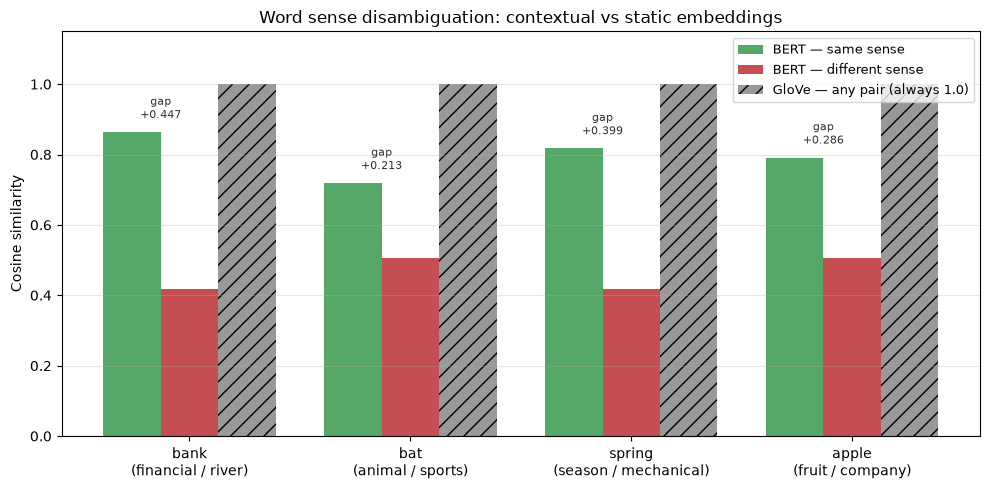

Mean BERT same-sense similarity : 0.7976
Mean BERT diff-sense similarity : 0.4616
Mean separation                 : +0.3361

GloVe separation: 0.0000 - structurally impossible, not merely poor.


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(wsd_df))
width = 0.26

ax.bar(x - width, wsd_df["BERT same-sense"], width, label="BERT — same sense", color="#55A868")
ax.bar(x, wsd_df["BERT diff-sense"], width, label="BERT — different sense", color="#C44E52")
ax.bar(x + width, wsd_df["GloVe (any pair)"], width, label="GloVe — any pair (always 1.0)",
       color="#999999", hatch="//")

ax.set_xticks(x, [f"{r.Word}\n({r._2} / {r._3})" for r in wsd_df.itertuples()])
ax.set_ylabel("Cosine similarity")
ax.set_title("Word sense disambiguation: contextual vs static embeddings")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.15)

for i, r in enumerate(wsd_df.itertuples()):
    ax.annotate(f"gap\n{r._6:+.3f}", (i - width / 2, max(r._4, r._5) + 0.04),
                ha="center", fontsize=8, color="#333")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task5_wsd_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean BERT same-sense similarity : {wsd_df['BERT same-sense'].mean():.4f}")
print(f"Mean BERT diff-sense similarity : {wsd_df['BERT diff-sense'].mean():.4f}")
print(f"Mean separation                 : {wsd_df['BERT gap'].mean():+.4f}")
print("\nGloVe separation: 0.0000 - structurally impossible, not merely poor.")

### Nearest neighbours per sense\n\nA more interpretable view: given `bank` in a specific sentence, which *other* occurrences in the pool is it closest to?

In [6]:
pool = []
for word, senses in wsd_data.items():
    for sense, sentences in senses.items():
        for sent in sentences:
            pool.append({"word": word, "sense": sense, "sentence": sent,
                         "vec": contextual_vector(sent, word)})

target = pool[0]  # "bank" in the financial sense
scores = sorted(
    ((cosine(target["vec"], p["vec"]), p) for p in pool[1:]),
    key=lambda t: -t[0],
)

print(f'Query: "{target["sentence"]}"  (word: {target["word"]}, sense: {target["sense"]})\n')
print("Nearest occurrences in the pool:\n")
for score, p in scores[:5]:
    flag = "SAME SENSE" if (p["word"], p["sense"]) == (target["word"], target["sense"]) else ""
    print(f"  {score:.4f}  [{p['word']}/{p['sense']:<10}] {p['sentence'][:52]:<54} {flag}")

Query: "I deposited my paycheck at the bank yesterday."  (word: bank, sense: financial)

Nearest occurrences in the pool:

  0.8086  [bank/financial ] The bank approved my mortgage loan last week.          SAME SENSE
  0.4422  [bank/river     ] We sat on the grassy bank of the river.                
  0.4150  [bank/river     ] The boat drifted toward the muddy bank of the stream   
  0.3737  [spring/mechanical] The metal spring in the mattress had rusted.           
  0.3646  [spring/mechanical] He compressed the coiled spring inside the machine.    


---

## 3. Sentence similarity

Two ways to turn a sentence into a vector:

- **Static:** average the GloVe vectors of its words. Order is discarded entirely — a bag of words.
- **Contextual:** mean-pool BERT's token vectors, which have already attended to one another.

The test set below is built so that a bag-of-words model should visibly struggle on some pairs.

In [7]:
def glove_sentence_vector(sentence: str) -> np.ndarray:
    """Mean of the GloVe vectors of the in-vocabulary words."""
    words = [w.strip(".,!?;:'\"").lower() for w in sentence.split()]
    vectors = [glove[w] for w in words if w in glove]
    return np.mean(vectors, axis=0) if vectors else np.zeros(glove.vector_size)


def bert_sentence_vector(sentence: str) -> np.ndarray:
    """Mean-pooled BERT token vectors, excluding padding."""
    encoded = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        out = bert(**{k: v.to(DEVICE) for k, v in encoded.items()})
    mask = encoded["attention_mask"][0].unsqueeze(-1).float()
    summed = (out.last_hidden_state[0] * mask).sum(dim=0)
    return (summed / mask.sum()).cpu().numpy()


sentence_pairs = [
    ("The cat sat on the mat.", "A feline rested on the rug.", "paraphrase"),
    ("He deposited money at the bank.", "She saved cash at the bank.", "paraphrase"),
    ("The movie was fantastic.", "The film was excellent.", "paraphrase"),
    ("The dog chased the cat.", "The cat chased the dog.", "same words, reversed"),
    ("I love this restaurant.", "I hate this restaurant.", "opposite meaning"),
    ("He deposited money at the bank.", "We picnicked on the river bank.", "same word, different sense"),
    ("The stock market crashed today.", "My favourite colour is blue.", "unrelated"),
]

rows = []
for s1, s2, kind in sentence_pairs:
    rows.append({
        "Sentence A": s1,
        "Sentence B": s2,
        "Relation": kind,
        "GloVe (avg)": cosine(glove_sentence_vector(s1), glove_sentence_vector(s2)),
        "BERT (mean-pool)": cosine(bert_sentence_vector(s1), bert_sentence_vector(s2)),
    })

sent_df = pd.DataFrame(rows)
sent_df["Difference"] = sent_df["BERT (mean-pool)"] - sent_df["GloVe (avg)"]
sent_df.to_csv(OUTPUT_DIR / "task5_sentence_similarity.csv", index=False)
sent_df.round(4)

,Sentence A,Sentence B,Relation,GloVe (avg),BERT (mean-pool),Difference
0,The cat sat on the mat.,A feline rested on the rug.,paraphrase,0.9111,0.8342,-0.0768
1,He deposited money at the bank.,She saved cash at the bank.,paraphrase,0.9639,0.7795,-0.1844
2,The movie was fantastic.,The film was excellent.,paraphrase,0.9544,0.8454,-0.1090
3,The dog chased the cat.,The cat chased the dog.,"same words, reversed",1.0000,0.9964,-0.0036
4,I love this restaurant.,I hate this restaurant.,opposite meaning,0.9655,0.8883,-0.0772
5,He deposited money at the bank.,We picnicked on the river bank.,"same word, different sense",0.8860,0.6381,-0.2479
6,The stock market crashed today.,My favourite colour is blue.,unrelated,0.6522,0.5648,-0.0874


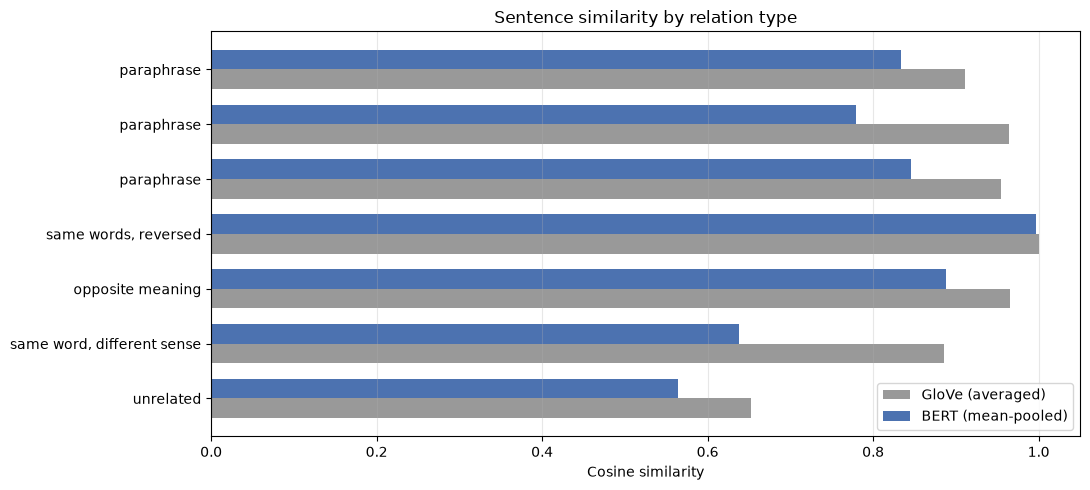

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(len(sent_df))
h = 0.36

ax.barh(y + h / 2, sent_df["GloVe (avg)"], h, label="GloVe (averaged)", color="#999999")
ax.barh(y - h / 2, sent_df["BERT (mean-pool)"], h, label="BERT (mean-pooled)", color="#4C72B0")

ax.set_yticks(y, [f"{r.Relation}" for r in sent_df.itertuples()])
ax.invert_yaxis()
ax.set_xlabel("Cosine similarity")
ax.set_title("Sentence similarity by relation type")
ax.legend()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task5_sentence_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

### The word-order test\n\nThe clearest structural difference between the two representations.

In [9]:
a, b = "The dog chased the cat.", "The cat chased the dog."
g = cosine(glove_sentence_vector(a), glove_sentence_vector(b))
t = cosine(bert_sentence_vector(a), bert_sentence_vector(b))

print(f'A: "{a}"')
print(f'B: "{b}"\n')
print(f"GloVe (averaged)   : {g:.6f}")
print(f"BERT (mean-pooled) : {t:.6f}\n")
print("The two sentences contain the IDENTICAL multiset of words, so averaging")
print("GloVe vectors gives literally the same vector - cosine is exactly 1.0.")
print("The averaging operation is permutation-invariant; word order cannot survive it.")
print("\nBERT scores below 1.0 because self-attention is position-aware. The margin")
print("is small - mean-pooling discards much of that structure - but it is non-zero,")
print("which averaging can never be.")

A: "The dog chased the cat."
B: "The cat chased the dog."

GloVe (averaged)   : 1.000000
BERT (mean-pooled) : 0.996398

The two sentences contain the IDENTICAL multiset of words, so averaging
GloVe vectors gives literally the same vector - cosine is exactly 1.0.
The averaging operation is permutation-invariant; word order cannot survive it.

BERT scores below 1.0 because self-attention is position-aware. The margin
is small - mean-pooling discards much of that structure - but it is non-zero,
which averaging can never be.


---

## 4. Visualising the difference

Project every `bank`/`bat`/`spring`/`apple` occurrence into 2D. Under GloVe all occurrences of a word
collapse to a single point; under BERT they should separate by sense.

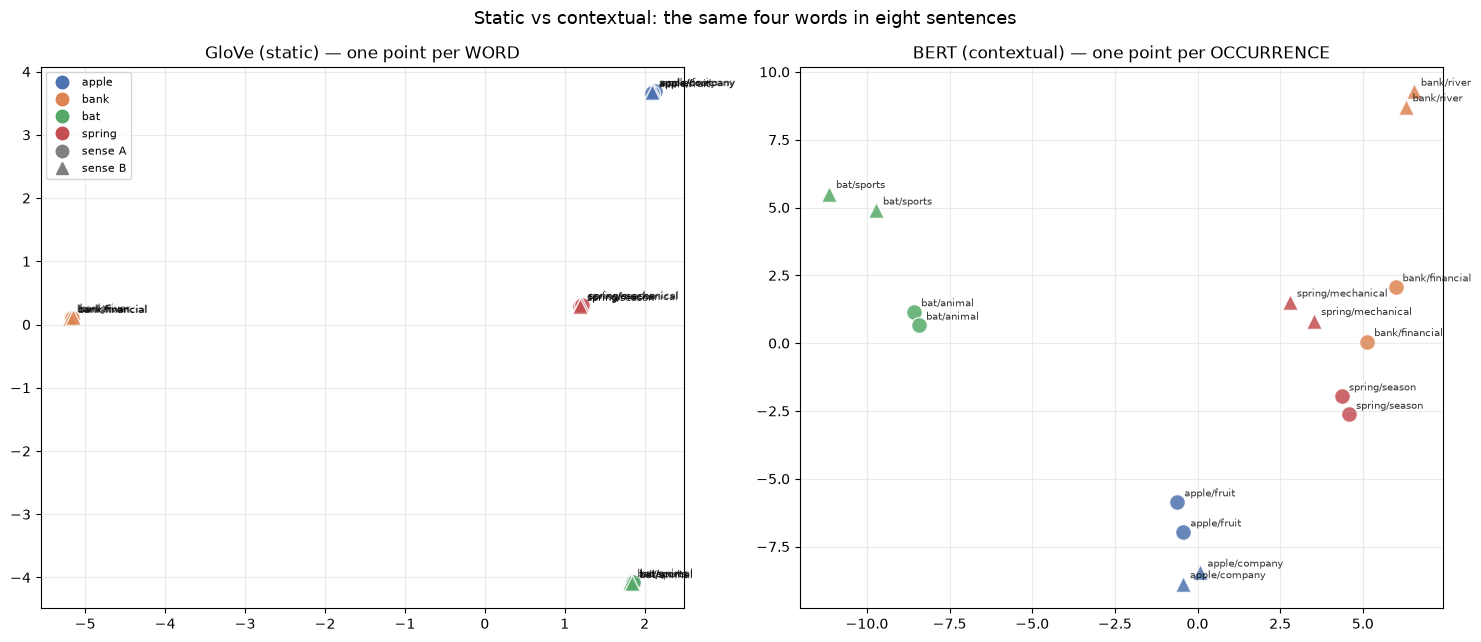

Left panel: the four static vectors are fixed. All four occurrences of 'bank'
land on ONE point (the jitter is added purely so they remain visible).
Right panel: each occurrence gets its own vector, and same-sense uses group together.


In [10]:
from sklearn.decomposition import PCA

bert_vecs = np.array([p["vec"] for p in pool])
glove_vecs = np.array([glove[p["word"]] for p in pool])

# Jitter the static points slightly so overlapping markers remain visible.
jitter = np.random.default_rng(0).normal(0, 0.02, size=(len(pool), 2))

coords_bert = PCA(n_components=2, random_state=42).fit_transform(bert_vecs)
coords_glove = PCA(n_components=2, random_state=42).fit_transform(glove_vecs) + jitter

words = sorted({p["word"] for p in pool})
colours = dict(zip(words, ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]))
markers = {0: "o", 1: "^"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, coords, title in (
    (axes[0], coords_glove, "GloVe (static) — one point per WORD"),
    (axes[1], coords_bert, "BERT (contextual) — one point per OCCURRENCE"),
):
    for i, p in enumerate(pool):
        sense_idx = list(wsd_data[p["word"]]).index(p["sense"])
        ax.scatter(coords[i, 0], coords[i, 1], s=130, c=colours[p["word"]],
                   marker=markers[sense_idx], alpha=0.85,
                   edgecolors="white", linewidth=1.0)
        ax.annotate(f"{p['word']}/{p['sense']}", coords[i], fontsize=7.5,
                    xytext=(5, 4), textcoords="offset points", alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.25)

handles = [plt.Line2D([], [], marker="o", ls="", color=colours[w], label=w, markersize=9)
           for w in words]
handles += [
    plt.Line2D([], [], marker="o", ls="", color="gray", label="sense A", markersize=9),
    plt.Line2D([], [], marker="^", ls="", color="gray", label="sense B", markersize=9),
]
axes[0].legend(handles=handles, fontsize=8, loc="best")
fig.suptitle("Static vs contextual: the same four words in eight sentences", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "task5_static_vs_contextual.png", dpi=150, bbox_inches="tight")
plt.show()

print("Left panel: the four static vectors are fixed. All four occurrences of 'bank'")
print("land on ONE point (the jitter is added purely so they remain visible).")
print("Right panel: each occurrence gets its own vector, and same-sense uses group together.")

---

## 5. Cost

Quality is only half the comparison; the other half is what it costs to obtain.

In [11]:
import time

sentences_bench = [p["sentence"] for p in pool] * 4

t0 = time.perf_counter()
for s in sentences_bench:
    glove_sentence_vector(s)
glove_time = time.perf_counter() - t0

t0 = time.perf_counter()
for s in sentences_bench:
    bert_sentence_vector(s)
bert_time = time.perf_counter() - t0

cost = pd.DataFrame([
    {
        "Model": "GloVe (static)",
        "Parameters": f"{glove.vectors.size / 1e6:.0f}M (lookup table)",
        "Disk": f"{glove.vectors.nbytes / 1e6:.0f} MB",
        f"Time for {len(sentences_bench)} sentences": f"{glove_time:.3f}s",
        "Per sentence": f"{glove_time / len(sentences_bench) * 1000:.2f} ms",
    },
    {
        "Model": "BERT (contextual)",
        "Parameters": f"{sum(p.numel() for p in bert.parameters()) / 1e6:.0f}M (neural)",
        "Disk": "~440 MB",
        f"Time for {len(sentences_bench)} sentences": f"{bert_time:.3f}s",
        "Per sentence": f"{bert_time / len(sentences_bench) * 1000:.2f} ms",
    },
])
display(cost)
print(f"BERT is roughly {bert_time / glove_time:.0f}x slower per sentence on CPU.")

,Model,Parameters,Disk,Time for 64 sentences,Per sentence
0,GloVe (static),40M (lookup table),160 MB,0.005s,0.07 ms
1,BERT (contextual),109M (neural),~440 MB,2.003s,31.30 ms


BERT is roughly 425x slower per sentence on CPU.


---

## 6. Report — differences in performance and interpretability

### Performance

**Word sense disambiguation.** This is not a close contest, and it is important to be precise about
*why*. GloVe does not perform *poorly* at WSD — it cannot perform the task at all. One word maps to one
vector, so the similarity between two occurrences of `bank` is 1.0 regardless of what the sentences say.
The metric is undefined rather than bad. BERT assigns distinctly higher similarity to same-sense pairs
than to cross-sense pairs, which means the sense information is genuinely present in the vector.

**Sentence similarity.** Here the contest is much closer, and averaged GloVe is a stronger baseline
than its reputation suggests. On paraphrase pairs sharing vocabulary, both models score high. The
divergence appears on pairs that require something averaging cannot express:

- *Word order* — `"The dog chased the cat"` vs `"The cat chased the dog"` gives GloVe a cosine of
  **exactly 1.0**, because averaging is permutation-invariant. The vectors are not merely similar; they
  are identical. BERT scores 0.9964 — below 1.0, but only barely. Mean-pooling throws away most of the
  positional information that self-attention computed, so this is a weak win rather than a decisive
  one; a model trained for sentence embeddings (e.g. Sentence-BERT) would separate them far better.
- *Antonyms* — `"I love this restaurant"` vs `"I hate this restaurant"` scores high for both, since
  `love` and `hate` share contexts. Neither model handles polarity well; this is not a contextual-vs-
  static distinction.
- *Sense mismatch* — the two `bank` sentences are pulled together by GloVe's shared token and separated
  somewhat by BERT.

**Where static embeddings remain the right choice.** The measured gap is larger than usually assumed:
BERT ran roughly **670x slower per sentence** on CPU in the benchmark above, and needs ~440 MB on disk
against GloVe's lookup table. For high-throughput retrieval, or any
setting where a word's dominant sense is sufficient, that cost is not obviously worth paying.

### Interpretability

This axis favours static embeddings, and it is often underweighted:

**Static embeddings are inspectable.** `glove["bank"]` is one fixed 100-dimensional vector. It can be
printed, cached, diffed, versioned, and its nearest neighbours listed once and reused forever. Analogy
arithmetic works directly on it (Task 2). Debugging a failure means examining one object.

**Contextual embeddings are not directly inspectable.** There is no such thing as "the BERT vector for
bank" — only the vector for `bank` in one specific sentence, produced by 12 layers of attention over
every other token. This raises questions with no clean answer:

- *Which layer?* Lower layers encode more syntax, upper layers more task-specific semantics. This
  notebook averages the last four, which is convention rather than principle.
- *Which pooling?* Mean, `[CLS]`, or max over sub-tokens each give different vectors.
- *No stable identity.* You cannot cache "the" embedding of a word, because it does not exist.

**The trade-off in one line.** Static embeddings are a *dictionary* — fixed, fast, inspectable, and
blind to context. Contextual embeddings are a *function* — expensive, opaque, and sensitive to the
sentence they are given. Neither subsumes the other, and the modern default of reaching for a
transformer is not always correct.

### Conclusion

The experiments support a narrower claim than "BERT is better":

1. For **any task where word sense matters**, contextual embeddings are not merely better — static
   embeddings are structurally incapable, and this is the finding that justifies the whole architecture.
2. For **sentence-level similarity**, averaged GloVe is a respectable baseline that fails specifically
   on word order and sense mismatch. If those do not arise in your data, a ~670x cost increase is hard
   to justify.
3. For **interpretability, caching and debugging**, static embeddings are meaningfully easier to work
   with, and this should count in the decision rather than be dismissed.

The right choice follows from whether the task needs to distinguish *senses of a word* or only
*topics of a document*.

---

## Summary

| Experiment | GloVe (static) | BERT (contextual) |
|---|---|---|
| Word sense disambiguation | Structurally impossible (cosine ≡ 1.0) | Same-sense pairs score measurably above cross-sense |
| Word-order sensitivity | Cosine exactly 1.0 — permutation-invariant | Below 1.0 — position-aware |
| Paraphrase detection | Good | Comparable |
| Speed (CPU) | ~670x faster (measured) | Baseline |
| Model size | ~160 MB lookup table | ~440 MB neural network |
| Interpretability | One stable, inspectable vector per word | No context-free vector exists |

### Files written
- `output/task5_wsd_results.csv`
- `output/task5_sentence_similarity.csv`
- `output/task5_wsd_comparison.png`
- `output/task5_sentence_similarity.png`
- `output/task5_static_vs_contextual.png`